# Lecture: Visualizing Text Data

Text contains information, but it does not arrive as ready-to-plot quantitative or categorical features. To analyze text, we must decide what to measure, translate that idea into a reproducible operation, and check whether the operation captures the meaning we intended.


## Learning goals

By the end of this lesson, you should be able to:

- explain why text must be converted into features before most visual analysis;
- describe why text preparation is needed before words can be counted;
- recognize how string methods and regular expressions help prepare text;
- compare word clouds with word-frequency bar charts;
- compare text-derived quantitative features across groups; and
- state conclusions and limitations supported by text-derived evidence.

## Install WordCloud if needed

`wordcloud` is not included automatically in every Python environment. Run the next cell before the imports if it has not been installed in the current environment. If it is already installed, the command will report that the requirement is satisfied.

In [27]:
%pip install wordcloud

## Import the libraries

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Comparing Universal Studios visitor reviews

Visitor reviews can help park managers understand what people noticed, valued, or found frustrating. A star rating provides a quick summary, but it does not explain *why* a visitor selected that rating. The written review may mention attractions, waiting, staff, food, cost, cleanliness, or a mixture of positive and negative experiences.

Universal Studios operates parks with different attractions and in different cultural and geographic settings. Visitors may also arrive with different expectations and have different experiences at each location. Comparing the reviews can help us discover which similarities and differences appear in what visitors chose to write about.


## The reproducible analysis workflow

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can answer the question?
3. **Operation:** What should the code select, calculate, or visualize?
4. **Check:** Does the result have sensible rows, values, units, and missingness?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Step 1 — Question

Universal Studios Florida, Japan, and Singapore differ in their attractions, settings, and visitor populations. Visitors may therefore arrive with different expectations and have different experiences at each location.

> **What aspects of the visitor experience appeared most often in reviews of Universal Studios Florida, Japan, and Singapore, and how did the reviews differ among the three locations?**

We will compare rating frequencies, commonly used words, and review lengths across the three locations.

## Step 2 — Data

The local dataset contains fixed random samples of 1,200 English-language reviews from each Universal Studios location: Florida, Japan, and Singapore. It was derived from the CC0 *Reviews of Universal Studios* dataset published on Kaggle. Reviewer names were removed.

Equal sample sizes keep one location from dominating the text displays. They do **not** indicate that the locations received equal numbers of reviews in the source data. The source contains many more Florida and Singapore reviews than Japan reviews.

The source reviews extend through May 2021, so the analysis describes historical reviews rather than current park conditions.

Source: https://www.kaggle.com/datasets/dwiknrd/reviewuniversalstudio

In [29]:
reviews = pd.read_csv(
    "data/universal_studios_reviews_sample.csv",
    parse_dates=["review_date"]
)

reviews.head()


,review_id,location,rating,review_date,review_text
0,1,Florida,5.0,2004-02-17,"If you visit Orlando, you have to take two day..."
1,2,Florida,5.0,2005-01-03,I think these parks (Universal Studios and Isl...
2,3,Florida,1.0,2005-03-31,"3 hours to get on a ride, $5 icees and $7 for ..."
3,4,Florida,5.0,2005-06-08,We really had a great time at this park. My 7 ...
4,5,Florida,4.0,2006-01-24,"After spending time in the Keys, we decided to..."


In [30]:
reviews.tail()

,review_id,location,rating,review_date,review_text
3595,3596,Singapore,5.0,2020-08-20,Hesitated to purchase a specific gift from my ...
3596,3597,Singapore,5.0,2020-08-26,"Love it now, lesser crowds and faster queues f..."
3597,3598,Singapore,2.0,2020-09-05,Well a lot of the restaurants are closed insid...
3598,3599,Singapore,4.0,2020-09-12,"Visited during phase2 period, the crowd is les..."
3599,3600,Singapore,5.0,2021-04-05,It was a nice day spent in Universal Studios. ...


In [31]:
reviews.shape


(3600, 5)

In [32]:
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    3600 non-null   int64         
 1   location     3600 non-null   object        
 2   rating       3600 non-null   float64       
 3   review_date  3600 non-null   datetime64[ns]
 4   review_text  3600 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 140.8+ KB


In [33]:
reviews.isnull().sum()

review_id      0
location       0
rating         0
review_date    0
review_text    0
dtype: int64

### Data dictionary

| Feature | Type | Description |
| --- | --- | --- |
| `review_id` | Identifier | Course-dataset identifier; it is not a reviewer identifier |
| `location` | Categorical | Universal Studios location: Florida, Japan, or Singapore |
| `rating` | Ordinal categorical | Visitor rating from 1 to 5 stars |
| `review_date` | Datetime | Date displayed with the review |
| `review_text` | Text | Written visitor review |

### Discussion: check the review data

1. What does one row represent?
2. Complete the table using the data dictionary and the output above.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `review_id` | identifier | int64 | 0 |
| `location` | categorical | object | 0 |
| `rating` | ordinal categorical | float64 | 0 |
| `review_date` | temporal | datetime64 | 0 |
| `review_text` | text | object | 0 |

3. Why do equal location sample sizes not mean that the locations received equal numbers of reviews in the source data?

A rating is **ordinal**: five stars indicate a more favorable rating than four stars, but the difference between five and four is not guaranteed to represent exactly the same change in opinion as the difference between two and one.


## Step 3 — Operation

To compare the reviews, we need to turn parts of the text into calculated features that can be summarized and visualized. The provided code:

1. estimates the number of words in each review;
2. converts the text to lowercase;
3. extracts individual words;
4. places each word in its own row; and
5. removes common words that are not useful for this comparison.

These are common text-preparation steps. Our emphasis in this lesson is on interpreting the resulting evidence rather than reproducing every intermediate coding step.

In [34]:
reviews["review_length_words"] = reviews["review_text"].str.split().str.len()
reviews["text_lower"] = reviews["review_text"].str.lower()
reviews["words"] = reviews["text_lower"].str.findall(r"\b[a-z']+\b")

words = reviews[["review_id", "location", "words"]].explode("words")
words = words.rename(columns={"words": "word"})

stopwords = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "ride", "rides", #added "ride" and "rides" to remove from graphics
    "for", "from", "had", "has", "have", "he", "her", "his", "i", "if",
    "in", "is", "it", "its", "me", "my", "of", "on", "or", "our", "she",
    "so", "that", "the", "their", "them", "they", "this", "to", "us", "was",
    "we", "were", "with", "you", "your", "universal", "park", "parks"
}

words_for_frequency = words.loc[
    ~words["word"].isin(stopwords)
    & words["word"].str.len().ge(3)
].copy()

The original `review_text` remains in the DataFrame. Keeping it allows us to return to complete reviews when a numerical or visual pattern needs context.

## Step 4 — Check

Text operations can run without an error and still measure the wrong thing. Before making figures, check the calculated review lengths, the number of reviews from each location, and examples of the prepared words.

In [35]:
reviews[
    [
        "review_id",
        "location",
        "rating",
        "review_date",
        "review_text",
        "review_length_words"
    ]
].isna().sum()


review_id              0
location               0
rating                 0
review_date            0
review_text            0
review_length_words    0
dtype: int64

In [36]:
reviews["rating"].value_counts().sort_index()


rating
1.0     136
2.0     146
3.0     400
4.0    1054
5.0    1864
Name: count, dtype: int64

### Discussion: compare high- and low-rating frequencies

1. Are high ratings of four or five stars more frequent than low ratings of one or two stars in this dataset?
2. What information about the three locations is hidden when all reviews are combined in one frequency table?

In [37]:
reviews["location"].value_counts().sort_index()


location
Florida      1200
Japan        1200
Singapore    1200
Name: count, dtype: int64

In [38]:
reviews["review_length_words"].describe().round(1)


count    3600.0
mean      114.4
std       125.9
min         8.0
25%        42.0
50%        76.0
75%       138.0
max      2253.0
Name: review_length_words, dtype: float64

## Step 5 — Evidence

We will compare the three Universal Studios locations using several views of the reviews:

1. rating frequencies provide context for the written reviews;
2. word clouds provide an initial visual impression;
3. word-frequency bar charts support more precise comparisons; and
4. review-length distributions show how much visitors wrote.

### Compare rating frequencies across locations

The overall frequency table showed that high ratings were more common than low ratings. A grouped bar plot lets us check whether that pattern appears at each location. Because the dataset contains the same number of sampled reviews from every location, the bar heights can be compared directly.

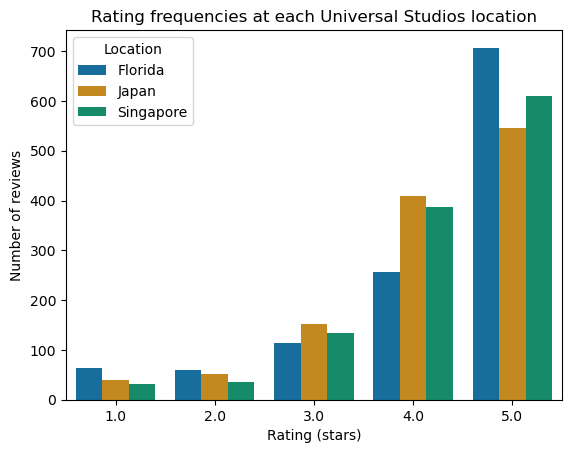

In [39]:
location_order = ["Florida", "Japan", "Singapore"]

sns.countplot(
    data=reviews,
    x="rating",
    hue="location",
    hue_order=location_order,
    palette="colorblind"
)

plt.xlabel("Rating (stars)")
plt.ylabel("Number of reviews")
plt.title("Rating frequencies at each Universal Studios location")
plt.legend(title="Location")
plt.show()

### Discussion: compare rating frequencies by location

1. Are four- and five-star ratings more common than one- and two-star ratings at all three locations?
2. Which location has the largest number of five-star reviews?
3. Why can the bar heights be compared directly in this dataset?

### Compare word clouds across locations

A **word cloud** represents more frequent words with larger type. It can provide a quick visual impression, but area and font size are difficult to compare precisely. Word placement is decorative; a word near another word does not mean the two are related.

The text-processing and WordCloud code is provided so that we can focus on interpretation. The settings used below are:

- `width` and `height`: the pixel dimensions used to construct each cloud;
- `background_color="white"`: a readable white background;
- `colormap="viridis"`: the named Matplotlib color palette;
- `max_words=75`: at most 75 words in each cloud;
- `collocations=False`: display individual words rather than automatically detected phrases; and
- `random_state=412`: keep the otherwise partly random arrangement reproducible.

Each cloud scales its own most frequent word to the largest size. Font sizes can therefore be compared **within** a cloud but not reliably **between** clouds.

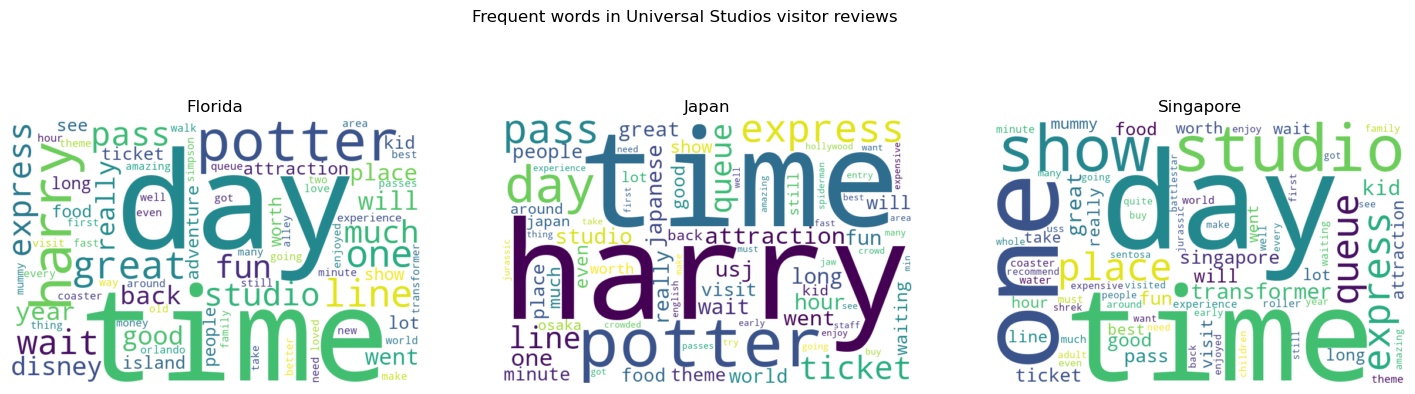

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, location in zip(axes, location_order):
    location_text = " ".join(
        words_for_frequency.loc[
            words_for_frequency["location"].eq(location),
            "word"
        ]
    )

    cloud = WordCloud(
        width=700,
        height=450,
        background_color="white",
        colormap="viridis",
        max_words=75,
        collocations=False,
        random_state=412
    ).generate(location_text)

    axis.imshow(cloud, interpolation="bilinear")
    axis.set_title(location)
    axis.axis("off")

fig.suptitle("Frequent words in Universal Studios visitor reviews")
plt.show()

### Discussion: compare the word clouds

1. What possible differences do you notice among the three word clouds?
2. Which comparisons are difficult or impossible to make from the clouds?
3. Is there another stopword that might make the clouds more informative? Why would you remove it?

### Compare word frequencies across locations

Word-frequency bar charts use a shared numeric scale, making the counts easier to compare than font sizes in separate word clouds. The provided code calculates the 15 most frequent prepared words for each location and creates three charts with the same horizontal scale.

The words are ordered from most to least frequent, and the vertical axes are inverted so the most frequent word appears at the top of each chart.

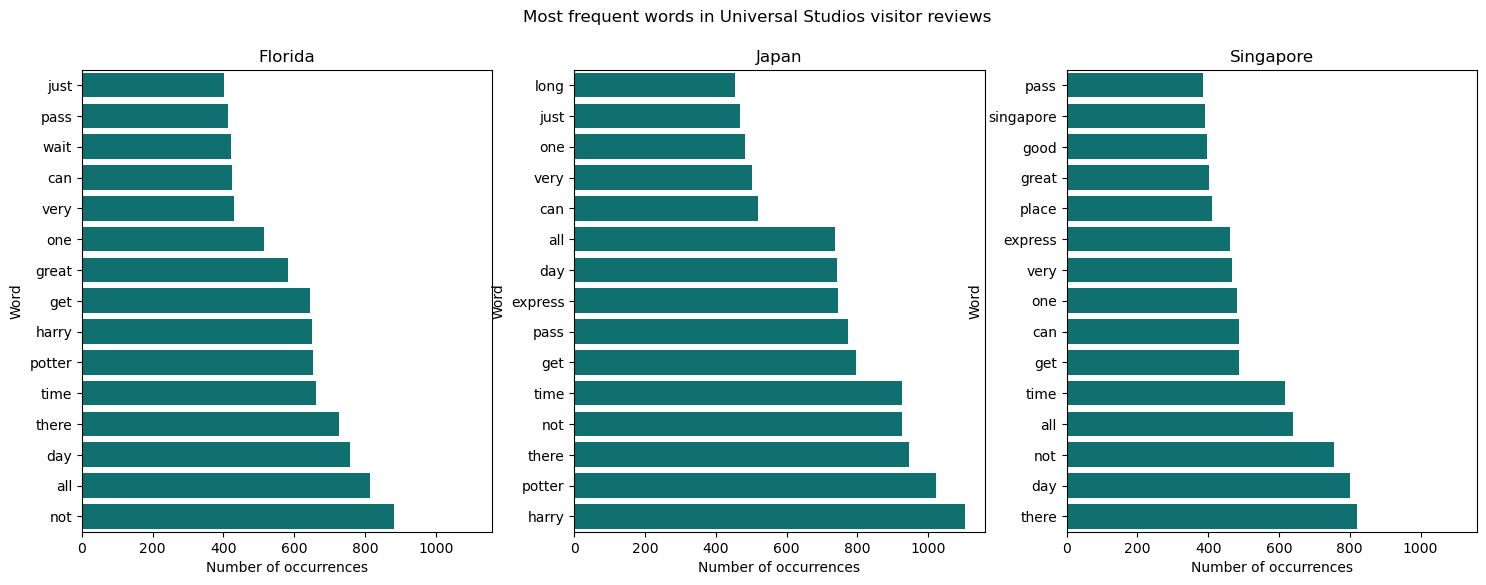

In [41]:
top_words_by_location = {}

for location in location_order:
    top_words_by_location[location] = (
        words_for_frequency.loc[
            words_for_frequency["location"].eq(location),
            "word"
        ]
        .value_counts()
        .head(15)
        .sort_values(ascending=False)
        .rename_axis("word")
        .reset_index(name="frequency")
    )

largest_frequency = max(
    table["frequency"].max()
    for table in top_words_by_location.values()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for axis, location in zip(axes, location_order):
    sns.barplot(
        data=top_words_by_location[location],
        x="frequency",
        y="word",
        color="teal",
        ax=axis
    )
    axis.set_xlim(0, largest_frequency * 1.05)
    axis.set_xlabel("Number of occurrences")
    axis.set_ylabel("Word")
    axis.set_title(location)
    axis.invert_yaxis()

fig.suptitle("Most frequent words in Universal Studios visitor reviews")
plt.show()

### Discussion: compare the word-frequency charts

1. What do the bar charts make easier to compare than the word clouds?
2. Which words appear prominently at all three locations?
3. Which words appear especially prominent at only one or two locations?
4. Why should raw word counts still be interpreted cautiously, even though each location has the same number of sampled reviews?

### Compare review length across locations

Review length is a quantitative feature constructed from the text. A box plot shows the median, middle 50%, whiskers, and potential outliers for each location. This comparison helps us decide whether differences in the amount of text could influence the raw word frequencies.

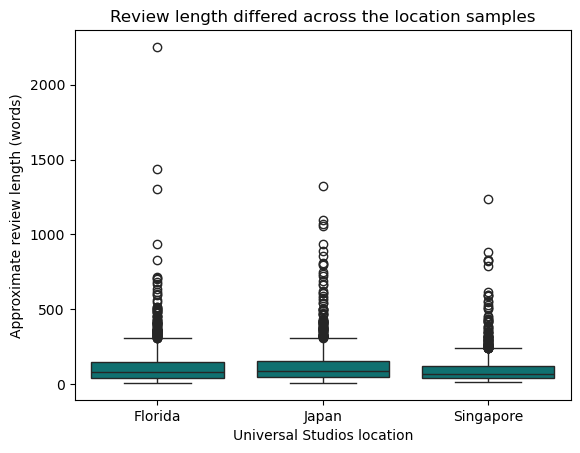

In [46]:
sns.boxplot(
    data=reviews,
    x="location",
    y="review_length_words",
    order=location_order,
    color="teal"
)

plt.xlabel("Universal Studios location")
plt.ylabel("Approximate review length (words)")
plt.title("Review length differed across the location samples")
plt.show()

In [43]:
reviews.groupby("location")["review_length_words"].describe().round(1).reindex(
    location_order
)

,count,mean,std,min,25%,50%,75%,max
location,,,,,,,,
Florida,1200.0,119.9,138.2,8.0,41.0,79.0,148.0,2253.0
Japan,1200.0,125.3,132.4,9.0,48.0,86.0,151.2,1325.0
Singapore,1200.0,98.0,102.6,13.0,39.0,65.0,119.0,1235.0


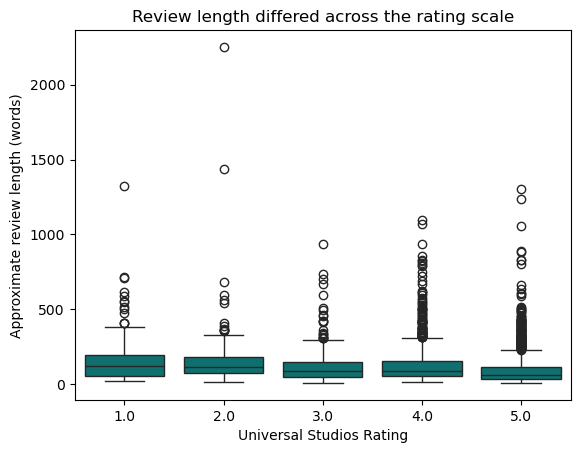

In [44]:
sns.boxplot(
    data=reviews,
    x="rating",
    y="review_length_words",
    #order=location_order,
    color="teal"
)

plt.xlabel("Universal Studios Rating")
plt.ylabel("Approximate review length (words)")
plt.title("Review length differed across the rating scale")
plt.show()

### Discussion: compare review length

1. Which location has the highest median review length?
2. Which location shows the greatest variability in review length?
3. How could differences in review length affect the word-frequency charts?
4. What does review length reveal, and what can it not tell us about the visitor experience?

## Step 6: Conclusion and limitation

High ratings were common at all three locations, although their rating distributions were not identical. The word clouds provided a quick impression of the reviews, while the bar charts made the most frequent words easier to compare. Review lengths also differed: the median review was longest for Japan, followed by Florida and Singapore. Together, these views show that the three historical review samples shared common vocabulary but differed in both the words visitors used and how much they wrote.

### Limitation

Word frequency does not preserve word order, context, sarcasm, negation, or whether a visitor used a term positively or negatively. Stopword choices can also change which terms appear prominent, and longer reviews create more opportunities for words to occur. The analysis retains only reviews detected as English, so it may exclude important perspectives—especially in Japan and Singapore. Online reviewers are self-selected and may not represent all visitors. Finally, the reviews end by May 2021, so the results should not be presented as evidence about current park operations or as proof that location caused the differences.

# What happened to the original text?

| Representation | What it preserves | What it loses |
| --- | --- | --- |
| Original review | Wording, order, context, and mixed opinions | Difficult to summarize across thousands of reviews |
| Word count | Approximate length | Nearly all meaning |
| Individual word frequency | Repeated vocabulary | Word order, document context, and tone |

Quantification makes comparison possible, but every conversion discards information. Responsible text analysis moves back and forth between numerical summaries and original examples.

## Discussion: review

1. What could you learn from the word clouds, and what comparisons did they make difficult?
2. What did the word-frequency charts make easier to compare?
3. How could differences in review length affect the word-frequency comparison?
4. How might restricting the analysis to English-language reviews affect Japan and Singapore?
5. What evidence would we need before claiming that location caused a difference in visitor experiences?
6. Which two visualizations would you retain if you had to summarize this analysis for park managers?